# 05 — GRACE Diagnostics

Reproduces paper **Fig. 10** (`GRACE_all_method_effects.png`),
**Fig. 11** (`cluster_hallucinating.png`), **Fig. 12**
(`gg_centric_rep_fragmentation.png`).


In [5]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as scipy_stats

# Ensure working directory is the repo root so relative paths resolve correctly.
_repo_root = Path(__file__).resolve().parent.parent if '__file__' in dir() else Path.cwd()
if (_repo_root / 'grace').is_dir():
    os.chdir(_repo_root)
elif (_repo_root.parent / 'grace').is_dir():
    os.chdir(_repo_root.parent)

from grace.analysis.load_results import load_summary_results, load_optuna_history
from grace.diagnostics.alignment import alignment_per_layer
from grace.diagnostics.fragmentation import pl_ra_correlation
from grace.diagnostics.pair_heatmap import per_pair_similarity

FIG_DIR = Path('Images'); FIG_DIR.mkdir(exist_ok=True)
MODELS = {'gemma2': 'google/gemma-2-2b-it', 'gemma3': 'google/gemma-3-27b-it',
          'llama3': 'meta-llama/Llama-3.3-70B-Instruct'}
MODEL_SHORT = {'gemma2': 'Gemma2-2B', 'gemma3': 'Gemma3-27B', 'llama3': 'Llama-70B'}
MODEL_COLORS = {
    'gemma2': '#e74c3c',
    'gemma3': '#3498db',
    'llama3': '#2ecc71',
}
CONCEPTS = sorted(p.stem for p in Path('concepts/gpt-5/extract').glob('*.json'))

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

print(f"CWD: {Path.cwd()}")
print(f"Concepts: {len(CONCEPTS)}")

CWD: /home/jtr2875/GRACE
Concepts: 20


## Fig. 10 — Per-(model, concept) Δsteerability vs. PV baseline for the 3 GRACE methods

For each (model, concept), look up the best-utility configuration for `pv`,
`unit_mean`, and `cluster`. Plot the per-method delta as a heatmap.


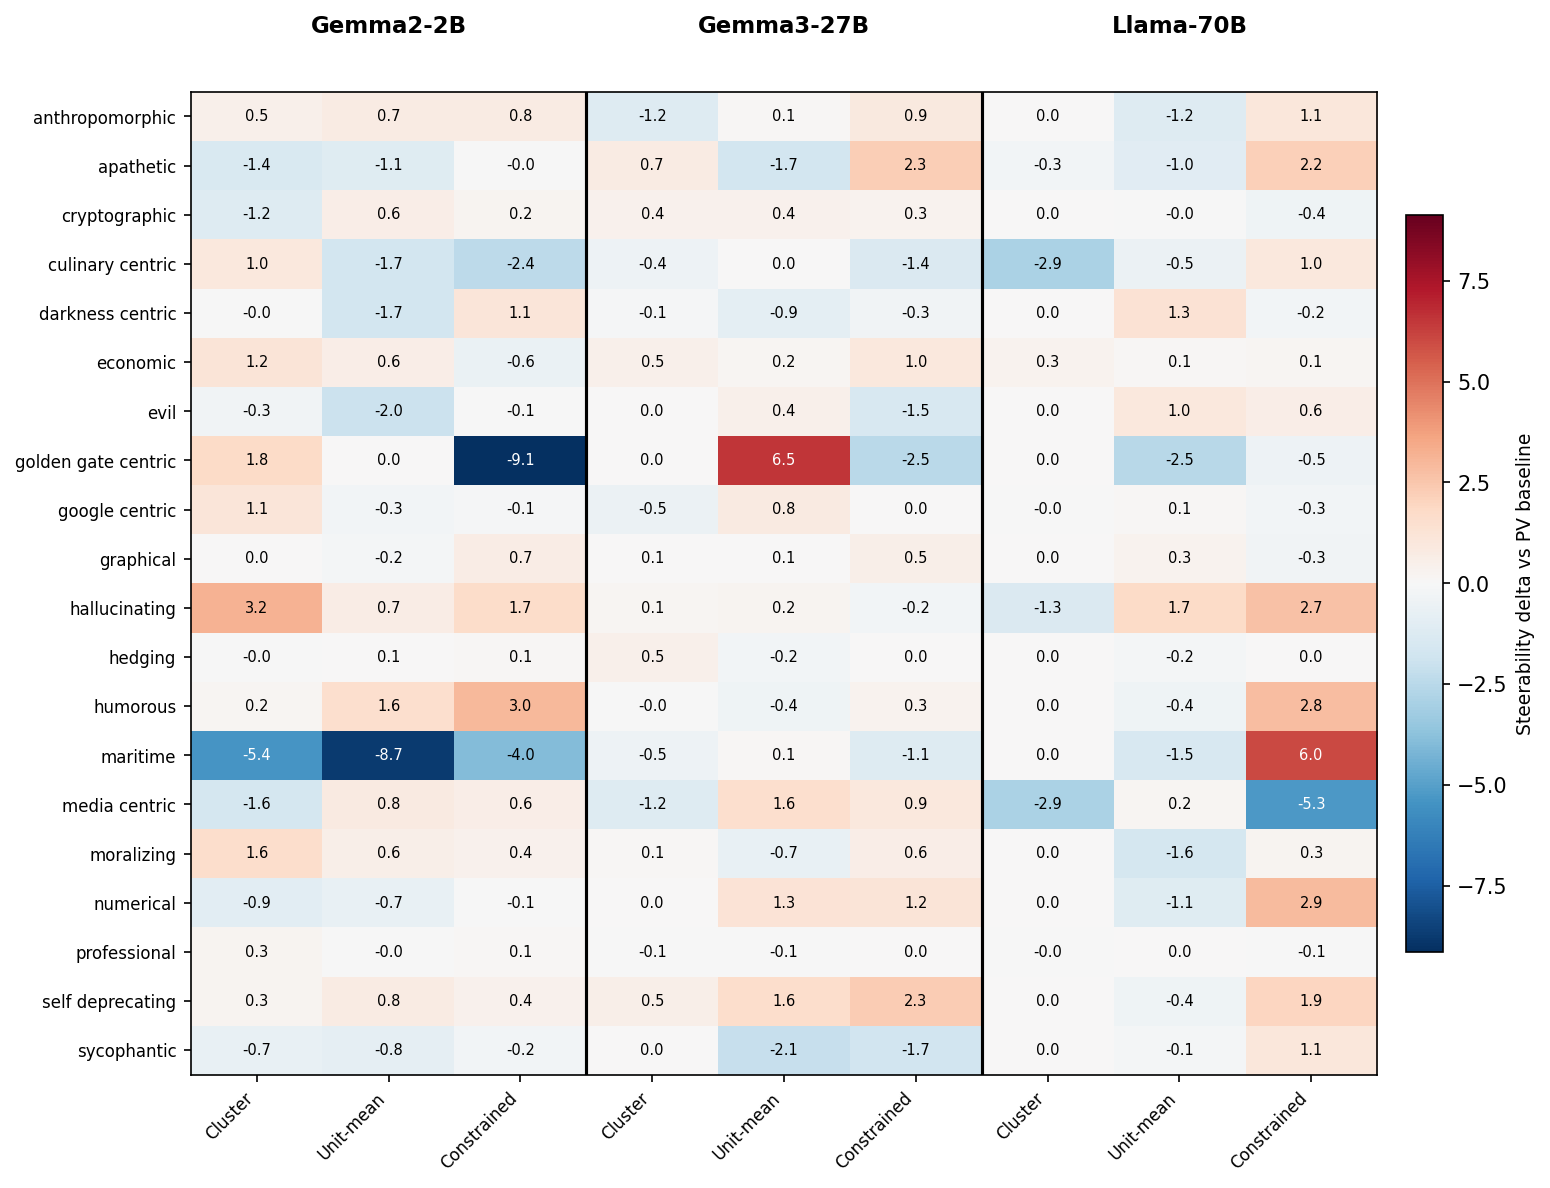

In [6]:
def optuna_best_per_seed(model_name, concept, method, mode):
    """Return list of per-seed best steerability from optuna trial histories."""
    rows = load_optuna_history(model_name, concept, method=method, mode=mode)
    if not rows:
        return []
    df = pd.DataFrame(rows)
    return [df[df['seed'] == s]['best_value_so_far'].max()
            for s in sorted(df['seed'].unique())]

def optuna_mean_best(model_name, concept, method, mode):
    """Mean of per-seed best steerability."""
    per_seed = optuna_best_per_seed(model_name, concept, method, mode)
    return float(np.mean(per_seed)) if per_seed else None

# Build delta tables per model: 3 methods (Cluster, Unit-mean, Constrained)
# All deltas use seed-averaged optuna best vs unconstrained PV baseline.
model_order = ['gemma2', 'gemma3', 'llama3']
delta_cols = ['cluster', 'unit_mean', 'constrained']
sub_labels = ['Cluster', 'Unit-mean', 'Constrained']

delta_tables = {}
for tag in model_order:
    mname = MODELS[tag]
    rows = []
    for c in CONCEPTS:
        pv_base = optuna_mean_best(mname, c, 'pv', 'unconstrained')
        if pv_base is None:
            rows.append({'concept': c, 'cluster': np.nan, 'unit_mean': np.nan,
                         'constrained': np.nan})
            continue
        row = {'concept': c}

        # Cluster: unconstrained cluster optuna (seed-averaged)
        cl = optuna_mean_best(mname, c, 'cluster', 'unconstrained')
        row['cluster'] = (cl - pv_base) if cl is not None else np.nan

        # Unit-mean: unconstrained unit_mean optuna (seed-averaged)
        um = optuna_mean_best(mname, c, 'unit_mean', 'unconstrained')
        row['unit_mean'] = (um - pv_base) if um is not None else np.nan

        # Constrained: top15_pl PV optuna (seed-averaged)
        con = optuna_mean_best(mname, c, 'pv', 'top15_pl')
        row['constrained'] = (con - pv_base) if con is not None else np.nan

        rows.append(row)
    delta_tables[tag] = pd.DataFrame(rows).set_index('concept')

# Build (20 x 9) matrix: 3 methods x 3 models
n_methods = len(delta_cols)
blocks = []
col_labels = []
for tag in model_order:
    dt = delta_tables[tag]
    block = dt[delta_cols].reindex(CONCEPTS)
    blocks.append(block.values)
    for sl in sub_labels:
        col_labels.append(sl)
data = np.column_stack(blocks)

vmax = np.nanmax(np.abs(data))
fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(np.nan_to_num(data, nan=0), cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

# Annotate cells
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if np.isnan(val):
            txt = '--'
            color = 'gray'
        else:
            txt = f'{val:.1f}'
            color = 'white' if abs(val) > 0.55 * vmax else 'black'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

# Vertical separators between model groups
for sep in range(1, len(model_order)):
    ax.axvline(sep * n_methods - 0.5, color='black', linewidth=1.5)

# Model group labels above
for g, tag in enumerate(model_order):
    ax.text(g * n_methods + (n_methods - 1) / 2, -1.6, MODEL_SHORT[tag],
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=8, rotation=45, ha='right')
ax.set_yticks(range(len(CONCEPTS)))
ax.set_yticklabels([c.replace('_', ' ') for c in CONCEPTS], fontsize=8)
ax.set_xlim(-0.5, len(col_labels) - 0.5)
ax.set_ylim(len(CONCEPTS) - 0.5, -0.5)

cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('Steerability delta vs PV baseline', fontsize=9)

plt.tight_layout()
fig.savefig(FIG_DIR / 'GRACE_all_method_effects.png', dpi=300, bbox_inches='tight')
plt.show()

## Fig. 11 — Cluster diagnostic for `hallucinating`

> **Note:** This figure requires raw activation tensors for the
> `hallucinating` concept (~2.4 GB), which are not included in the
> repository. To reproduce, run the full activation-extraction pipeline
> first (see README).

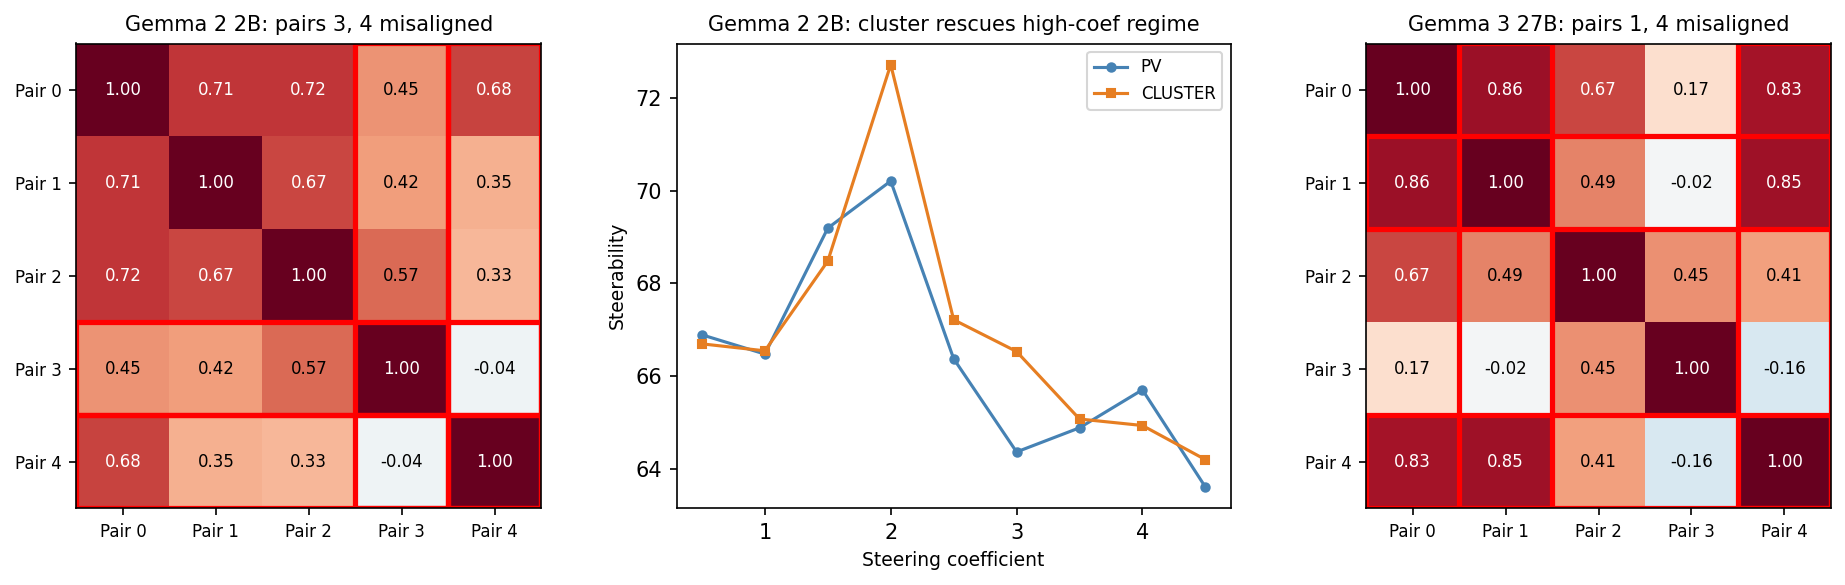

In [7]:
def plot_pair_sim_heatmap(ax, sims_dict, title, highlight_pairs=None):
    """Plot 5x5 cosine-similarity heatmap from per_pair_similarity output."""
    if not sims_dict:
        ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center')
        return
    avg_sim = np.mean(np.stack([s.numpy() for s in sims_dict.values()]), axis=0)
    n = avg_sim.shape[0]
    im = ax.imshow(avg_sim, cmap='RdBu_r', vmin=-1, vmax=1)

    # Annotate cells
    for i in range(n):
        for j in range(n):
            color = 'white' if abs(avg_sim[i, j]) > 0.6 else 'black'
            ax.text(j, i, f'{avg_sim[i, j]:.2f}', ha='center', va='center',
                    fontsize=8, color=color)

    # Red borders around highlighted pairs
    if highlight_pairs:
        for p in highlight_pairs:
            ax.add_patch(Rectangle((-0.5, p - 0.5), n, 1,
                                   fill=False, edgecolor='red', linewidth=2.5))
            ax.add_patch(Rectangle((p - 0.5, -0.5), 1, n,
                                   fill=False, edgecolor='red', linewidth=2.5))

    ax.set_xticks(range(n))
    ax.set_xticklabels([f'Pair {i}' for i in range(n)], fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels([f'Pair {i}' for i in range(n)], fontsize=8)
    ax.set_title(title, fontsize=10)
    return im

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Panel 1: Gemma 2 2B similarity heatmap
sims_2b = per_pair_similarity(MODELS['gemma2'], 'hallucinating', 'response_avg')
plot_pair_sim_heatmap(axes[0], sims_2b,
                      'Gemma 2 2B: pairs 3, 4 misaligned',
                      highlight_pairs=[3, 4])

# Panel 2: steerability vs coefficient comparison
ax = axes[1]
for method, color, marker in [('pv', 'steelblue', 'o'), ('cluster', '#e67e22', 's')]:
    rows = [r for r in load_summary_results(MODELS['gemma2'], 'hallucinating', method=method)
            if r.get('mean_utility') is not None]
    if not rows:
        continue
    mdf = pd.DataFrame(rows).groupby('coef')['mean_utility'].max().reset_index()
    ax.plot(mdf.coef, mdf.mean_utility, f'{marker}-', label=method.upper(),
            color=color, markersize=4, linewidth=1.5)
ax.set_xlabel('Steering coefficient', fontsize=9)
ax.set_ylabel('Steerability', fontsize=9)
ax.set_title('Gemma 2 2B: cluster rescues high-coef regime', fontsize=10)
ax.legend(fontsize=8)

# Panel 3: Gemma 3 27B similarity heatmap
sims_27b = per_pair_similarity(MODELS['gemma3'], 'hallucinating', 'response_avg')
plot_pair_sim_heatmap(axes[2], sims_27b,
                      'Gemma 3 27B: pairs 1, 4 misaligned',
                      highlight_pairs=[1, 4])

plt.tight_layout()
fig.savefig(FIG_DIR / 'cluster_hallucinating.png', dpi=300, bbox_inches='tight')
plt.show()

## Fig. 12 — Representational fragmentation diagnostic for `golden_gate_centric`

Left: PL/RA correlation across all (model, concept) pairs vs. constrained-search delta.
Right: layer profiles for `golden_gate_centric` on Gemma-2-2B (low correlation case).


/tmp/ipykernel_3123694/2123054874.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


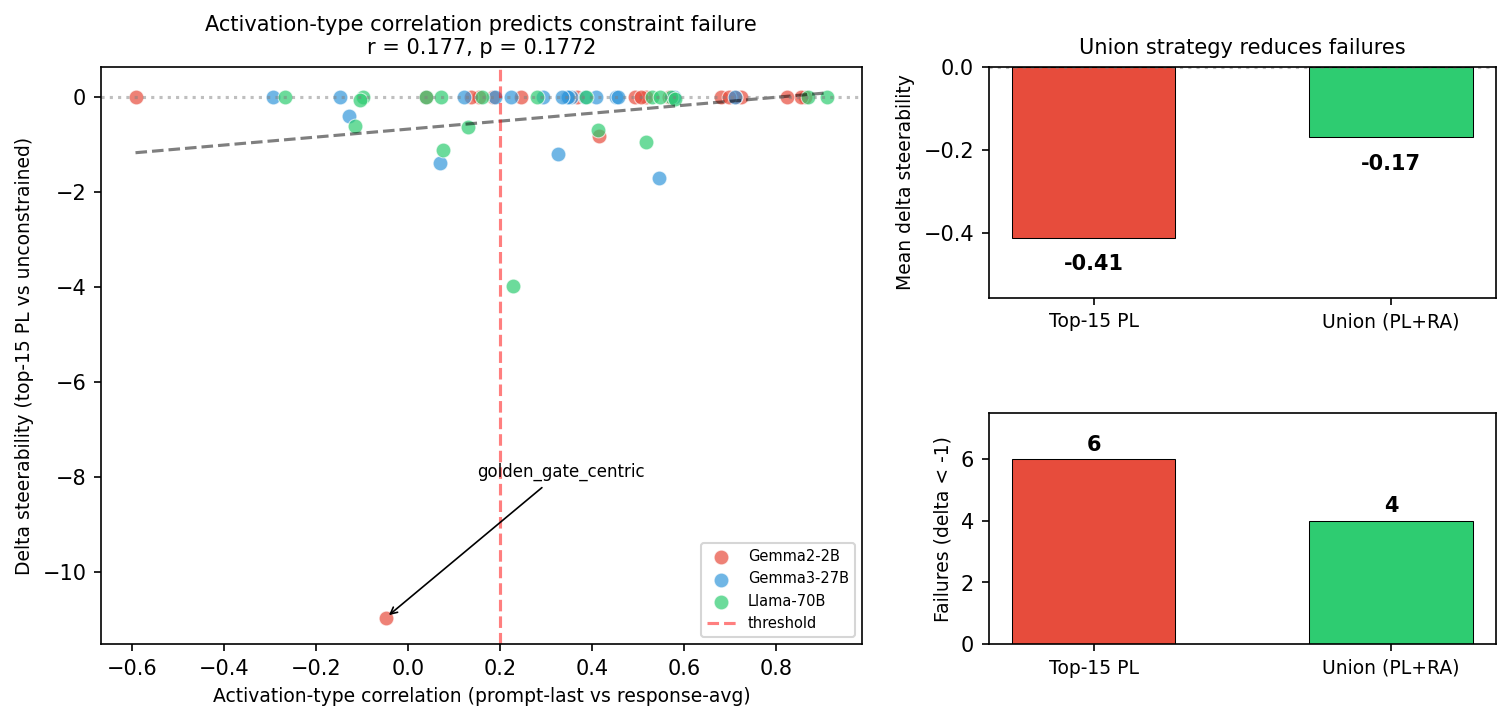

In [8]:
# Compute activation-type correlation and constrained-search delta
# for each (model, concept). The delta measures how much steerability you
# lose by restricting to top-15 PL layers vs searching all evaluated layers.
failure_rows = []
for tag, mname in MODELS.items():
    for c in CONCEPTS:
        try:
            act_r, A_pl, A_ra = pl_ra_correlation(mname, c)
        except FileNotFoundError:
            continue

        # Top-15 layers by each activation type
        all_layers = sorted(set(A_pl) & set(A_ra))
        top15_pl = set(sorted(all_layers, key=lambda l: A_pl.get(l, 0), reverse=True)[:15])
        top15_ra = set(sorted(all_layers, key=lambda l: A_ra.get(l, 0), reverse=True)[:15])
        top15_union = top15_pl | top15_ra

        # Best steerability from all PV evaluations vs restricted layer sets
        grid_rows = load_summary_results(mname, c, method='pv')
        if not grid_rows:
            continue
        gdf = pd.DataFrame(grid_rows).dropna(subset=['mean_utility'])
        if gdf.empty:
            continue
        best_overall = gdf['mean_utility'].max()

        def best_in_set(layer_set):
            sub = gdf[gdf['layer'].isin(layer_set)]
            return sub['mean_utility'].max() if not sub.empty else np.nan

        failure_rows.append({
            'model': tag, 'concept': c,
            'act_type_corr': act_r,
            'd_top15_pl': best_in_set(top15_pl) - best_overall,
            'd_top15_ra': best_in_set(top15_ra) - best_overall,
            'd_union': best_in_set(top15_union) - best_overall,
            'n_union': len(top15_union),
        })

fdf = pd.DataFrame(failure_rows)

# --- Plot ---
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[3, 2], hspace=0.5)

# Panel 1: scatter — activation-type correlation vs constraint delta
ax = fig.add_subplot(gs[:, 0])
for tag in ['gemma2', 'gemma3', 'llama3']:
    sub = fdf[fdf['model'] == tag]
    ax.scatter(sub['act_type_corr'], sub['d_top15_pl'], c=MODEL_COLORS[tag],
               label=MODEL_SHORT[tag], alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

valid = fdf[['act_type_corr', 'd_top15_pl']].dropna()
if len(valid) > 2:
    slope, intercept, r, p, se = scipy_stats.linregress(valid['act_type_corr'], valid['d_top15_pl'])
    x_range = np.linspace(valid['act_type_corr'].min(), valid['act_type_corr'].max(), 50)
    ax.plot(x_range, intercept + slope * x_range, 'k--', alpha=0.5, linewidth=1.5)
else:
    r, p = np.nan, np.nan

# golden_gate_centric annotation
gg = fdf[(fdf['model'] == 'gemma2') & (fdf['concept'] == 'golden_gate_centric')]
if not gg.empty:
    ax.annotate('golden_gate_centric', xy=(gg.iloc[0]['act_type_corr'], gg.iloc[0]['d_top15_pl']),
                xytext=(0.15, -8), fontsize=8,
                arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0.2, color='red', linestyle='--', alpha=0.5, label='threshold')
ax.set_xlabel('Activation-type correlation (prompt-last vs response-avg)', fontsize=9)
ax.set_ylabel('Delta steerability (top-15 PL vs unconstrained)', fontsize=9)
ax.set_title(f'Activation-type correlation predicts constraint failure\nr = {r:.3f}, p = {p:.4f}',
             fontsize=10)
ax.legend(fontsize=7, loc='lower right')

# Panel 2a (top-right): mean delta steerability — PL vs Union
ax2a = fig.add_subplot(gs[0, 1])
strategies = ['d_top15_pl', 'd_union']
strat_labels = ['Top-15 PL', 'Union (PL+RA)']
strat_colors = ['#e74c3c', '#2ecc71']
means = [fdf[s].mean() for s in strategies]

ax2a.bar(range(2), means, color=strat_colors, edgecolor='black', linewidth=0.5, width=0.55)
ax2a.axhline(0, color='gray', linestyle=':', alpha=0.5)
for i, m in enumerate(means):
    va = 'top' if m < 0 else 'bottom'
    offset = -0.04 if m < 0 else 0.04
    ax2a.text(i, m + offset, f'{m:.2f}', ha='center', va=va, fontsize=10, fontweight='bold')
ymin = min(means) * 1.35 if min(means) < 0 else -0.1
ax2a.set_ylim(bottom=ymin)
ax2a.set_xticks(range(2))
ax2a.set_xticklabels(strat_labels, fontsize=9)
ax2a.set_ylabel('Mean delta steerability', fontsize=9)
ax2a.set_title('Union strategy reduces failures', fontsize=10)

# Panel 2b (bottom-right): failure count (delta < -1)
ax2b = fig.add_subplot(gs[1, 1])
n_failures = [(fdf[s] < -1).sum() for s in strategies]
ax2b.bar(range(2), n_failures, color=strat_colors, edgecolor='black', linewidth=0.5, width=0.55)
for i, nf in enumerate(n_failures):
    ax2b.text(i, nf + 0.15, str(nf), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2b.set_xticks(range(2))
ax2b.set_xticklabels(strat_labels, fontsize=9)
ax2b.set_ylabel('Failures (delta < -1)', fontsize=9)
ax2b.set_ylim(0, max(n_failures) + 1.5 if max(n_failures) > 0 else 2)

plt.tight_layout()
fig.savefig(FIG_DIR / 'gg_centric_rep_fragmentation.png', dpi=300, bbox_inches='tight')
plt.show()